# Tutorial 17: Subgraphs in LangGraph

In this tutorial we explore Subgraphs — the ability to embed a compiled LangGraph graph as a single node inside a parent graph. Subgraphs enable modular, reusable agent logic and clean separation of concerns in complex workflows.

## 1. Why Subgraphs?

- **Modularity**: build a processing pipeline once and reuse it in multiple parent graphs
- **Encapsulation**: the child graph has its own private state that doesn't pollute the parent
- **Composability**: subgraphs can be nested to any depth
- **Independent checkpointing**: each level checkpoints separately

A subgraph can share state keys with its parent (shared schema keys are automatically merged) or maintain completely independent state (private keys remain invisible to the parent).

## 2. Setup

In [1]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langgraph.types import Command
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0.1,
)

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 3. Building a Document Processing Subgraph

We create a reusable document processing subgraph that:
1. Splits the document into chunks
2. Extracts key entities from each chunk
3. Produces a structured summary

This subgraph will then be embedded as a node inside a larger research workflow.

In [2]:
# --- Child graph state ---
# 'document' is shared with the parent (same key name)
# 'chunks' and 'entities' are private to the child
class DocProcessState(TypedDict):
    document: str       # shared with parent
    chunks: List[str]   # private to child
    entities: List[str] # private to child
    doc_summary: str    # shared with parent


def chunk_document(state: DocProcessState) -> DocProcessState:
    """Split document into ~200-character chunks."""
    text = state["document"]
    chunks = [text[i:i+200] for i in range(0, len(text), 200)]
    print(f"  [subgraph] Split into {len(chunks)} chunks.")
    return {"chunks": chunks}


def extract_entities(state: DocProcessState) -> DocProcessState:
    """Extract key entities from the first chunk."""
    if not state["chunks"]:
        return {"entities": []}
    sample = state["chunks"][0]
    response = llm.invoke([
        HumanMessage(content=f"List the key entities (people, places, concepts) in this text as a comma-separated list:\n{sample}")
    ])
    entities = [e.strip() for e in response.content.split(",")]
    print(f"  [subgraph] Extracted {len(entities)} entities.")
    return {"entities": entities}


def summarise_document(state: DocProcessState) -> DocProcessState:
    """Produce a concise summary of the full document."""
    response = llm.invoke([
        HumanMessage(content=f"Summarise this document in 2-3 sentences:\n{state['document']}")
    ])
    print(f"  [subgraph] Summary generated.")
    return {"doc_summary": response.content}


# Build child graph
doc_workflow = StateGraph(DocProcessState)
doc_workflow.add_node("chunk_document", chunk_document)
doc_workflow.add_node("extract_entities", extract_entities)
doc_workflow.add_node("summarise_document", summarise_document)

doc_workflow.set_entry_point("chunk_document")
doc_workflow.add_edge("chunk_document", "extract_entities")
doc_workflow.add_edge("extract_entities", "summarise_document")
doc_workflow.add_edge("summarise_document", END)

doc_processing_subgraph = doc_workflow.compile()
print("Document processing subgraph compiled.")

Document processing subgraph compiled.


## 4. Building the Parent Graph

The parent graph orchestrates a research pipeline. The document processing step is handled entirely by the subgraph — the parent just knows it receives a `doc_summary`.

In [3]:
# --- Parent graph state ---
# 'document' and 'doc_summary' are shared keys (same names as in child)
class ResearchState(TypedDict):
    topic: str
    document: str      # passed into subgraph
    doc_summary: str   # received from subgraph
    final_report: str


def fetch_document(state: ResearchState) -> ResearchState:
    """Simulate fetching a document for the research topic."""
    # In production this would call a real document retrieval service
    doc = (
        f"Research document on: {state['topic']}. "
        "Artificial intelligence has made significant strides in recent years. "
        "Large language models like GPT-4 and Claude have demonstrated remarkable capabilities "
        "in reasoning, code generation, and multimodal understanding. "
        "The field continues to evolve rapidly with new architectures and training approaches. "
        "Key researchers include Yann LeCun, Geoffrey Hinton, and Andrew Ng. "
        "Major organisations investing heavily include OpenAI, Anthropic, Google DeepMind, and Meta AI."
    )
    print(f"[parent] Document fetched ({len(doc)} chars).")
    return {"document": doc}


def write_final_report(state: ResearchState) -> ResearchState:
    """Write a final research report using the document summary."""
    response = llm.invoke([
        HumanMessage(content=(
            f"Write a short research report on '{state['topic']}' "
            f"based on this summary:\n{state['doc_summary']}"
        ))
    ])
    print("[parent] Final report written.")
    return {"final_report": response.content}


# Build parent graph
research_workflow = StateGraph(ResearchState)
research_workflow.add_node("fetch_document", fetch_document)

# Embed the compiled child graph as a node
research_workflow.add_node("process_document", doc_processing_subgraph)

research_workflow.add_node("write_final_report", write_final_report)

research_workflow.set_entry_point("fetch_document")
research_workflow.add_edge("fetch_document", "process_document")
research_workflow.add_edge("process_document", "write_final_report")
research_workflow.add_edge("write_final_report", END)

research_app = research_workflow.compile()
print("Parent graph compiled.")

Parent graph compiled.


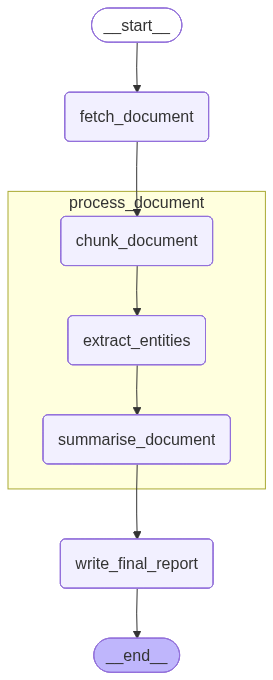

In [4]:
from IPython.display import Image, display
# xray=True shows the internal structure of subgraphs
display(Image(research_app.get_graph(xray=True).draw_mermaid_png()))

## 5. Running the Nested Workflow

In [5]:
result = research_app.invoke({
    "topic": "advances in artificial intelligence",
    "document": "",
    "doc_summary": "",
    "final_report": ""
})

print("\n=== FINAL REPORT ===")
print(result["final_report"])

[parent] Document fetched (524 chars).
  [subgraph] Split into 3 chunks.


  [subgraph] Extracted 3 entities.
  [subgraph] Summary generated.
[parent] Final report written.

=== FINAL REPORT ===
**Research Report: Advances in Artificial Intelligence**

**Introduction**

Artificial intelligence (AI) has witnessed significant advancements in recent years, driven by the development of large language models and innovative architectures. This report provides an overview of the current state of AI research, highlighting the key developments and trends that are shaping the field.

**Recent Breakthroughs**

One of the most notable advancements in AI is the emergence of large language models, such as GPT-4 and Claude. These models have demonstrated impressive capabilities in reasoning and multimodal understanding, surpassing human-like performance in various tasks. For instance, GPT-4 has shown exceptional proficiency in natural language processing, while Claude has excelled in multimodal understanding, enabling it to comprehend and respond to visual and auditory inpu

## 6. Navigating from Subgraph to Parent with Command

A node inside a subgraph can exit early and route in the parent graph using `Command(goto=..., graph=Command.PARENT)`.

In [6]:
from langgraph.types import Command as LGCommand

class ValidationState(TypedDict):
    text: str
    is_valid: bool
    error_message: str


def validate_input(state: ValidationState):
    """Validate input. If invalid, exit the subgraph and go directly to error_handler in parent."""
    if len(state["text"]) < 10:
        # Skip remaining subgraph nodes and jump to a parent node
        return LGCommand(
            update={"is_valid": False, "error_message": "Text too short (minimum 10 characters)"},
            goto="handle_error",
            graph=LGCommand.PARENT
        )
    return {"is_valid": True}


def process_valid_text(state: ValidationState) -> ValidationState:
    response = llm.invoke([HumanMessage(content=f"Summarise: {state['text']}" )])
    print("Processed:", response.content[:100])
    return state


# Child graph with early exit
child = StateGraph(ValidationState)
child.add_node("validate_input", validate_input)
child.add_node("process_valid_text", process_valid_text)
child.set_entry_point("validate_input")
child.add_edge("validate_input", "process_valid_text")
child.add_edge("process_valid_text", END)
child_compiled = child.compile()


class ParentState(TypedDict):
    text: str
    is_valid: bool
    error_message: str


def handle_error(state: ParentState) -> ParentState:
    print(f"[parent] Error caught: {state['error_message']}")
    return state


parent = StateGraph(ParentState)
parent.add_node("child_processing", child_compiled)
parent.add_node("handle_error", handle_error)
parent.set_entry_point("child_processing")
parent.add_edge("child_processing", END)
parent.add_edge("handle_error", END)
parent_app = parent.compile()

# Test with invalid input (too short)
print("--- Short input ---")
parent_app.invoke({"text": "Hi", "is_valid": True, "error_message": ""})

# Test with valid input
print("\n--- Valid input ---")
parent_app.invoke({"text": "Artificial intelligence is transforming the world rapidly.", "is_valid": True, "error_message": ""})

--- Short input ---
[parent] Error caught: Text too short (minimum 10 characters)

--- Valid input ---
Processed: Artificial intelligence (AI) is indeed transforming the world at an unprecedented rate. Here's a sum


{'text': 'Artificial intelligence is transforming the world rapidly.',
 'is_valid': True,
 'error_message': ''}

## 7. Conclusion

In this tutorial we explored Subgraphs:
- Embedding a compiled child graph as a node with `workflow.add_node("name", compiled_subgraph)`
- Shared state keys flow automatically between parent and child
- `Command(goto=..., graph=Command.PARENT)` for early exit from a subgraph back to the parent
- `xray=True` in `get_graph()` to visualise nested structure

In Tutorial 18 we explore the `Send` API for dynamic parallelization and the Map-Reduce pattern.